In [1]:
# STEP 01 -  library import  and  random seed fix

import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# STEP 02 - GitHub raw URL dataset automatically load
DATA_URL = "https://raw.githubusercontent.com/abir945/AI_ML_LAB/main/DT/dataset/train.csv"

if "YOUR_USERNAME" in DATA_URL:
    raise ValueError("DATA_URL replace koro. GitHub raw CSV link ekhane dite hobe.")

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (10443, 7)


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


In [4]:
# STEP 03 - Dataset structure, column type, basic summary

print("Columns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nNumerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include="object"))

Columns:
['experience', 'country', 'education', 'languages', 'frameworks', 'company_size', 'salary_usd']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10443 entries, 0 to 10442
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   experience    10442 non-null  float64
 1   country       10443 non-null  object 
 2   education     10443 non-null  object 
 3   languages     10443 non-null  object 
 4   frameworks    10443 non-null  object 
 5   company_size  10443 non-null  object 
 6   salary_usd    10443 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 571.2+ KB

Numerical Summary:


,experience,salary_usd
count,10442.000000,10443.000000
mean,19.878472,131736.778129
std,11.815038,46195.765324
min,0.000000,12064.000000
25%,10.000000,98291.500000
50%,20.000000,131291.000000
75%,30.000000,164217.500000
max,40.000000,273362.000000



Categorical Summary:


,country,education,languages,frameworks,company_size
count,10443,10443,10443,10443,10443
unique,10,5,100,100,6
top,USA,Bachelors,"PHP, PHP","Laravel, Vue",51-200
freq,4102,5242,139,133,1773


In [5]:
# STEP 04 - Missing values, duplicate rows, unusual category values check

print("Missing values per column:")
display(df.isnull().sum().to_frame("missing_count"))

print("Duplicate rows:", df.duplicated().sum())

print("\nUnique values in categorical columns:")
categorical_cols_temp = df.select_dtypes(include="object").columns

for col in categorical_cols_temp:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))

Missing values per column:


,missing_count
experience,1
country,0
education,0
languages,0
frameworks,0
company_size,0
salary_usd,0


Duplicate rows: 0

Unique values in categorical columns:

country:
country
USA          4102
UK           1104
Germany      1046
Canada       1027
India        1011
France        585
Australia     527
Japan         498
Singapore     285
Brazil        258
Name: count, dtype: int64

education:
education
Bachelors       5242
Masters         3136
Some College    1045
High School      518
PhD              502
Name: count, dtype: int64

languages:
languages
PHP, PHP            139
Java, Python        129
Java, JavaScript    123
Ruby, Swift         120
JavaScript, Rust    120
Swift, Rust         119
C++, PHP            118
JavaScript, C++     118
Swift, Java         117
Python, C++         116
Name: count, dtype: int64

frameworks:
frameworks
Laravel, Vue              133
Spring, ASP.NET           128
Express, Laravel          127
Laravel, React            124
Ruby on Rails, Vue        123
React, React              121
Vue, Ruby on Rails        120
Ruby on Rails, Angular    120
Flask, ASP.NET

In [6]:
# STEP 05 - company_size column-er Excel formatting problem clean

df["company_size"] = df["company_size"].replace({
    "10-Jan": "1-10",
    "Nov-50": "11-50"
})

print("Cleaned company_size values:")
print(df["company_size"].value_counts())

Cleaned company_size values:
company_size
51-200       1773
1001-5000    1756
1-10         1747
201-1000     1746
5000+        1745
11-50        1676
Name: count, dtype: int64


In [7]:
# STEP 06 - salary_usd থেকে binary classification target high_salary তৈরি করা

salary_median = df["salary_usd"].median()

df["high_salary"] = (df["salary_usd"] > salary_median).astype(int)

print("Median Salary:", salary_median)
print("\nTarget class distribution:")
display(df["high_salary"].value_counts().to_frame("count"))

print("\nTarget class percentage:")
display((df["high_salary"].value_counts(normalize=True) * 100).to_frame("percentage"))

Median Salary: 131291.0

Target class distribution:


,count
high_salary,
0,5222
1,5221



Target class percentage:


,percentage
high_salary,
0,50.004788
1,49.995212


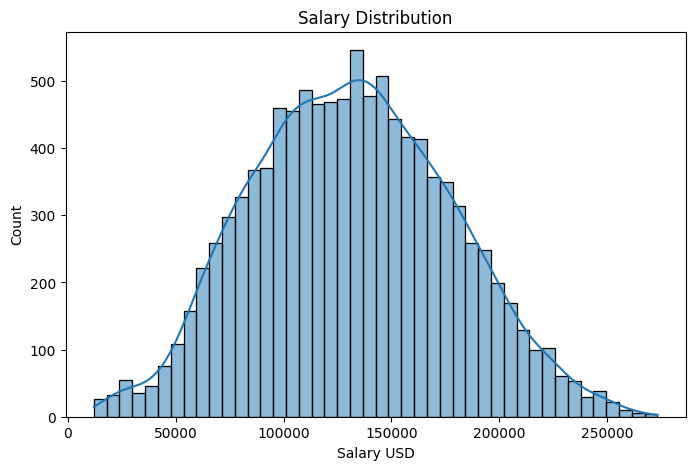

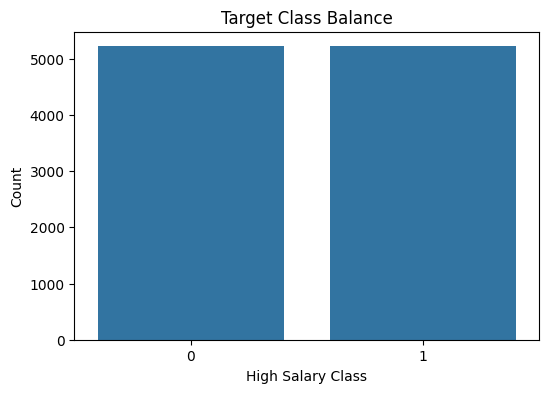

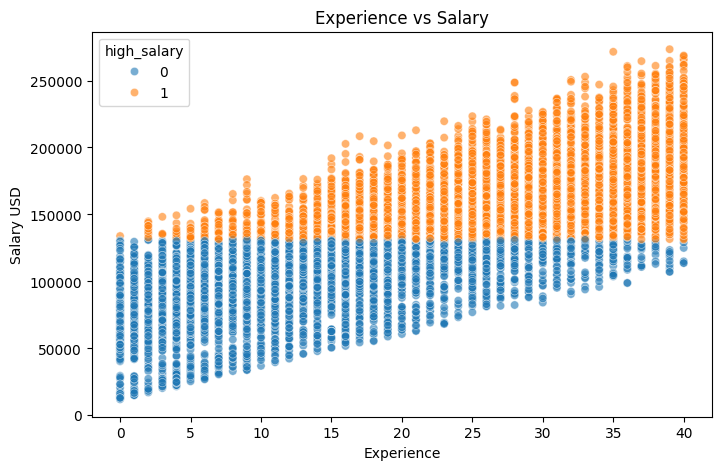

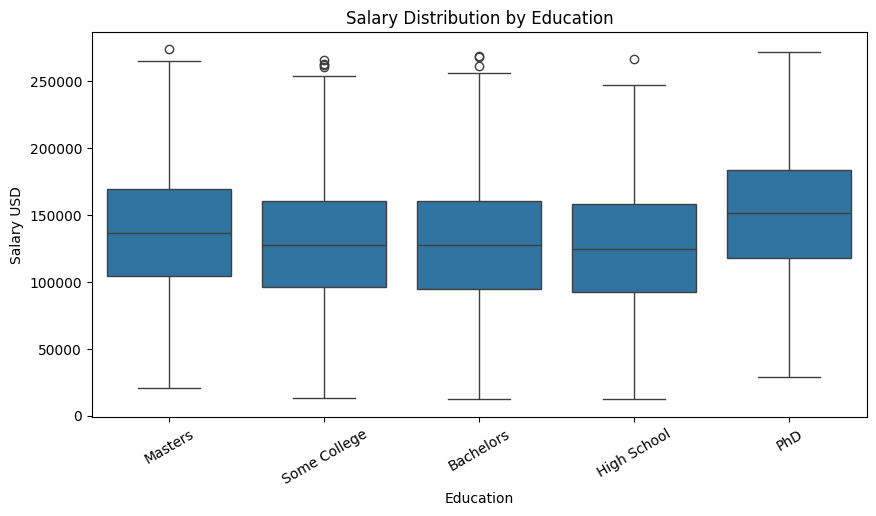

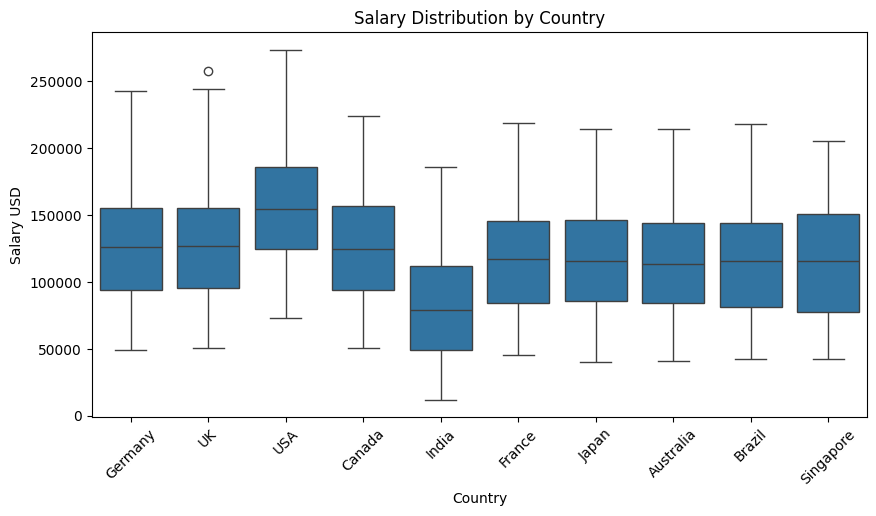

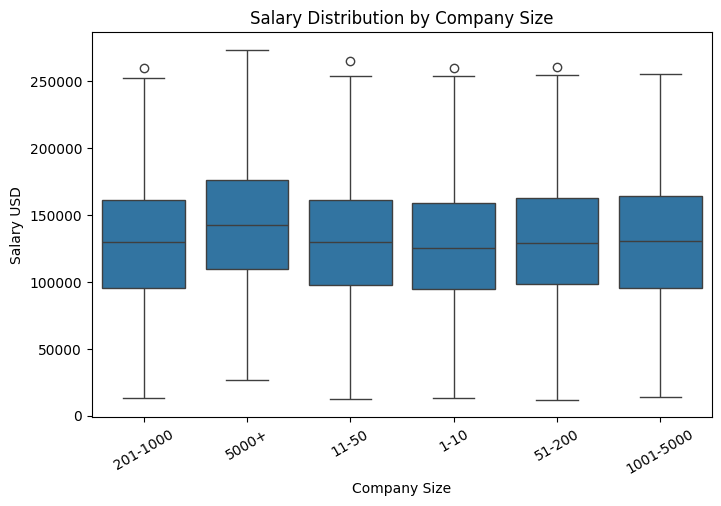

In [8]:
# STEP 07 - Assignment-er extra data exploration-er jonno important plots তৈরি করা

plt.figure(figsize=(8, 5))
sns.histplot(df["salary_usd"], kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary USD")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x="high_salary", data=df)
plt.title("Target Class Balance")
plt.xlabel("High Salary Class")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="experience", y="salary_usd", hue="high_salary", data=df, alpha=0.6)
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary USD")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="education", y="salary_usd", data=df)
plt.title("Salary Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Salary USD")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="country", y="salary_usd", data=df)
plt.title("Salary Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Salary USD")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="company_size", y="salary_usd", data=df)
plt.title("Salary Distribution by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary USD")
plt.xticks(rotation=30)
plt.show()

In [9]:
# STEP 08 - Features X এবং target y আলাদা করা

X = df.drop(columns=["salary_usd", "high_salary"])
y = df["high_salary"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

print("X shape:", X.shape)
print("y shape:", y.shape)

Numerical features: ['experience']
Categorical features: ['country', 'education', 'languages', 'frameworks', 'company_size']
X shape: (10443, 6)
y shape: (10443,)


In [10]:
# STEP 09 - Stratified train/test split করা, তারপর validation split করা

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))

print("\nValidation class balance:")
print(y_val.value_counts(normalize=True))

print("\nTest class balance:")
print(y_test.value_counts(normalize=True))

Train shape: (6683, 6)
Validation shape: (1671, 6)
Test shape: (2089, 6)

Train class balance:
high_salary
1    0.500075
0    0.499925
Name: proportion, dtype: float64

Validation class balance:
high_salary
0    0.500299
1    0.499701
Name: proportion, dtype: float64

Test class balance:
high_salary
0    0.500239
1    0.499761
Name: proportion, dtype: float64


In [11]:
# STEP 10 - Missing value imputation, scaling, one-hot encoding pipeline তৈরি করা

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = X_train_processed.astype(np.float32)
X_val_processed = X_val_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

y_train_array = y_train.values.astype(np.float32)
y_val_array = y_val.values.astype(np.float32)
y_test_array = y_test.values.astype(np.float32)

input_dim = X_train_processed.shape[1]

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Input dimension for NN:", input_dim)

Processed train shape: (6683, 222)
Processed validation shape: (1671, 222)
Processed test shape: (2089, 222)
Input dimension for NN: 222


In [13]:
# STEP 11 - PyTorch Dataset class এবং DataLoader function তৈরি করা

class TabularDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X_data = torch.tensor(X_data, dtype=torch.float32)
        self.y_data = torch.tensor(y_data, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X_data)

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]


train_dataset = TabularDataset(X_train_processed, y_train_array)
val_dataset = TabularDataset(X_val_processed, y_val_array)
test_dataset = TabularDataset(X_test_processed, y_test_array)

def create_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [15]:
# STEP 12 - Different activation function dynamically select করার helper function

def get_activation(name):
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "sigmoid":
        return nn.Sigmoid()
    else:
        raise ValueError("Unsupported activation function")

In [16]:
# STEP 13 - Shallow Neural Network তৈরি করা, যেখানে exactly one hidden layer আছে

class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units=32, activation="relu"):
        super(ShallowNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            get_activation(activation),
            nn.Linear(hidden_units, 1)
        )

    def forward(self, x):
        return self.network(x)

In [17]:
# STEP 14 - Deep Neural Network তৈরি করা, যেখানে at least three hidden layers এবং dropout regularization আছে

class DeepNN(nn.Module):
    def __init__(self, input_dim, activation="relu", dropout_rate=0.30):
        super(DeepNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            get_activation(activation),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            get_activation(activation),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            get_activation(activation),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [18]:
# STEP 15 - Model training, validation, prediction, metrics calculation-er reusable function তৈরি করা

criterion = nn.BCEWithLogitsLoss()

def get_optimizer(optimizer_name, model, learning_rate, weight_decay=0.0):
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay
        )

    else:
        raise ValueError("Unsupported optimizer")


def evaluate_loss_accuracy(model, data_loader):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * X_batch.size(0)
            total_correct += (predictions == y_batch).sum().item()
            total_samples += X_batch.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def train_model(model, train_loader, val_loader, optimizer, epochs):
    model = model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate_loss_accuracy(model, train_loader)
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} "
            f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
        )

    model.load_state_dict(best_model_state)

    return model, history


def get_predictions(model, data_loader):
    model.eval()

    all_probs = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()

            all_probs.extend(probs)
            all_true.extend(y_batch.numpy().flatten())

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)

    all_pred = (all_probs >= 0.5).astype(int)

    return all_true, all_pred, all_probs


def evaluate_final_model(model, data_loader):
    y_true, y_pred, y_prob = get_predictions(model, data_loader)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred)
    }

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    metrics["fpr"] = fpr
    metrics["tpr"] = tpr
    metrics["thresholds"] = thresholds

    return metrics

In [19]:
# STEP 16 - Shallow NN tuning : hidden units, activation function, batch size

shallow_grid = []

for hidden_units in [32, 64, 128]:
    for activation in ["relu", "tanh", "sigmoid"]:
        for batch_size in [32, 64]:
            shallow_grid.append({
                "hidden_units": hidden_units,
                "activation": activation,
                "batch_size": batch_size,
                "epochs": 35,
                "learning_rate": 0.001,
                "optimizer": "adam"
            })

best_shallow_score = -1
best_shallow_model = None
best_shallow_history = None
best_shallow_params = None
shallow_tuning_results = []

for params in shallow_grid:
    print("\nTraining Shallow NN with params:", params)

    train_loader, val_loader, test_loader = create_loaders(params["batch_size"])

    model = ShallowNN(
        input_dim=input_dim,
        hidden_units=params["hidden_units"],
        activation=params["activation"]
    )

    optimizer = get_optimizer(
        optimizer_name=params["optimizer"],
        model=model,
        learning_rate=params["learning_rate"]
    )

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        epochs=params["epochs"]
    )

    val_metrics = evaluate_final_model(trained_model, val_loader)
    val_score = val_metrics["auc"]

    shallow_tuning_results.append({
        **params,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    if val_score > best_shallow_score:
        best_shallow_score = val_score
        best_shallow_model = trained_model
        best_shallow_history = history
        best_shallow_params = params

print("\nBest Shallow NN Params:")
print(best_shallow_params)

shallow_results_df = pd.DataFrame(shallow_tuning_results)
display(shallow_results_df.sort_values(by="val_auc", ascending=False))


Training Shallow NN with params: {'hidden_units': 32, 'activation': 'relu', 'batch_size': 32, 'epochs': 35, 'learning_rate': 0.001, 'optimizer': 'adam'}
Epoch [1/35] Train Loss: 0.2958 | Val Loss: 0.3073 Train Acc: 0.8900 | Val Acc: 0.8851
Epoch [2/35] Train Loss: 0.2267 | Val Loss: 0.2452 Train Acc: 0.8966 | Val Acc: 0.8905
Epoch [3/35] Train Loss: 0.2154 | Val Loss: 0.2388 Train Acc: 0.8975 | Val Acc: 0.8923
Epoch [4/35] Train Loss: 0.2128 | Val Loss: 0.2397 Train Acc: 0.8985 | Val Acc: 0.8905
Epoch [5/35] Train Loss: 0.2109 | Val Loss: 0.2411 Train Acc: 0.8991 | Val Acc: 0.8899
Epoch [6/35] Train Loss: 0.2104 | Val Loss: 0.2431 Train Acc: 0.9003 | Val Acc: 0.8893
Epoch [7/35] Train Loss: 0.2102 | Val Loss: 0.2438 Train Acc: 0.8985 | Val Acc: 0.8887
Epoch [8/35] Train Loss: 0.2094 | Val Loss: 0.2446 Train Acc: 0.9008 | Val Acc: 0.8917
Epoch [9/35] Train Loss: 0.2088 | Val Loss: 0.2453 Train Acc: 0.9017 | Val Acc: 0.8923
Epoch [10/35] Train Loss: 0.2083 | Val Loss: 0.2457 Train Acc: 

KeyboardInterrupt: 

In [20]:
# STEP 17 - Deep NN tuning : learning rate, optimizer, training epochs

deep_grid = []

for learning_rate in [0.001, 0.0005]:
    for optimizer_name in ["adam", "sgd"]:
        for epochs in [40, 60]:
            deep_grid.append({
                "learning_rate": learning_rate,
                "optimizer": optimizer_name,
                "epochs": epochs,
                "batch_size": 64,
                "activation": "relu",
                "dropout_rate": 0.30,
                "weight_decay": 0.0001
            })

best_deep_score = -1
best_deep_model = None
best_deep_history = None
best_deep_params = None
deep_tuning_results = []

for params in deep_grid:
    print("\nTraining Deep NN with params:", params)

    train_loader, val_loader, test_loader = create_loaders(params["batch_size"])

    model = DeepNN(
        input_dim=input_dim,
        activation=params["activation"],
        dropout_rate=params["dropout_rate"]
    )

    optimizer = get_optimizer(
        optimizer_name=params["optimizer"],
        model=model,
        learning_rate=params["learning_rate"],
        weight_decay=params["weight_decay"]
    )

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        epochs=params["epochs"]
    )

    val_metrics = evaluate_final_model(trained_model, val_loader)
    val_score = val_metrics["auc"]

    deep_tuning_results.append({
        **params,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    if val_score > best_deep_score:
        best_deep_score = val_score
        best_deep_model = trained_model
        best_deep_history = history
        best_deep_params = params

print("\nBest Deep NN Params:")
print(best_deep_params)

deep_results_df = pd.DataFrame(deep_tuning_results)
display(deep_results_df.sort_values(by="val_auc", ascending=False))


Training Deep NN with params: {'learning_rate': 0.001, 'optimizer': 'adam', 'epochs': 40, 'batch_size': 64, 'activation': 'relu', 'dropout_rate': 0.3, 'weight_decay': 0.0001}
Epoch [1/40] Train Loss: 0.2392 | Val Loss: 0.2599 Train Acc: 0.8897 | Val Acc: 0.8791
Epoch [2/40] Train Loss: 0.2162 | Val Loss: 0.2501 Train Acc: 0.9035 | Val Acc: 0.8911
Epoch [3/40] Train Loss: 0.2092 | Val Loss: 0.2526 Train Acc: 0.9030 | Val Acc: 0.8887
Epoch [4/40] Train Loss: 0.1983 | Val Loss: 0.2500 Train Acc: 0.9078 | Val Acc: 0.8923
Epoch [5/40] Train Loss: 0.1896 | Val Loss: 0.2502 Train Acc: 0.9126 | Val Acc: 0.8875
Epoch [6/40] Train Loss: 0.1788 | Val Loss: 0.2591 Train Acc: 0.9186 | Val Acc: 0.8845
Epoch [7/40] Train Loss: 0.1646 | Val Loss: 0.2546 Train Acc: 0.9277 | Val Acc: 0.8857
Epoch [8/40] Train Loss: 0.1461 | Val Loss: 0.2676 Train Acc: 0.9389 | Val Acc: 0.8839
Epoch [9/40] Train Loss: 0.1344 | Val Loss: 0.2868 Train Acc: 0.9455 | Val Acc: 0.8791
Epoch [10/40] Train Loss: 0.1158 | Val Lo

KeyboardInterrupt: 

In [21]:
# STEP 18 - Best Shallow NN এবং Best Deep NN test set-e evaluate করা

_, _, shallow_test_loader = create_loaders(best_shallow_params["batch_size"])
_, _, deep_test_loader = create_loaders(best_deep_params["batch_size"])

shallow_test_metrics = evaluate_final_model(best_shallow_model, shallow_test_loader)
deep_test_metrics = evaluate_final_model(best_deep_model, deep_test_loader)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    "Shallow NN": [
        shallow_test_metrics["accuracy"],
        shallow_test_metrics["precision"],
        shallow_test_metrics["recall"],
        shallow_test_metrics["f1"],
        shallow_test_metrics["auc"]
    ],
    "Deep NN": [
        deep_test_metrics["accuracy"],
        deep_test_metrics["precision"],
        deep_test_metrics["recall"],
        deep_test_metrics["f1"],
        deep_test_metrics["auc"]
    ]
})

display(comparison_df)

,Metric,Shallow NN,Deep NN
0,Accuracy,0.886070,0.883676
1,Precision,0.885277,0.874649
2,Recall,0.886973,0.895594
3,F1-Score,0.886124,0.884998
4,AUC,0.961766,0.962732


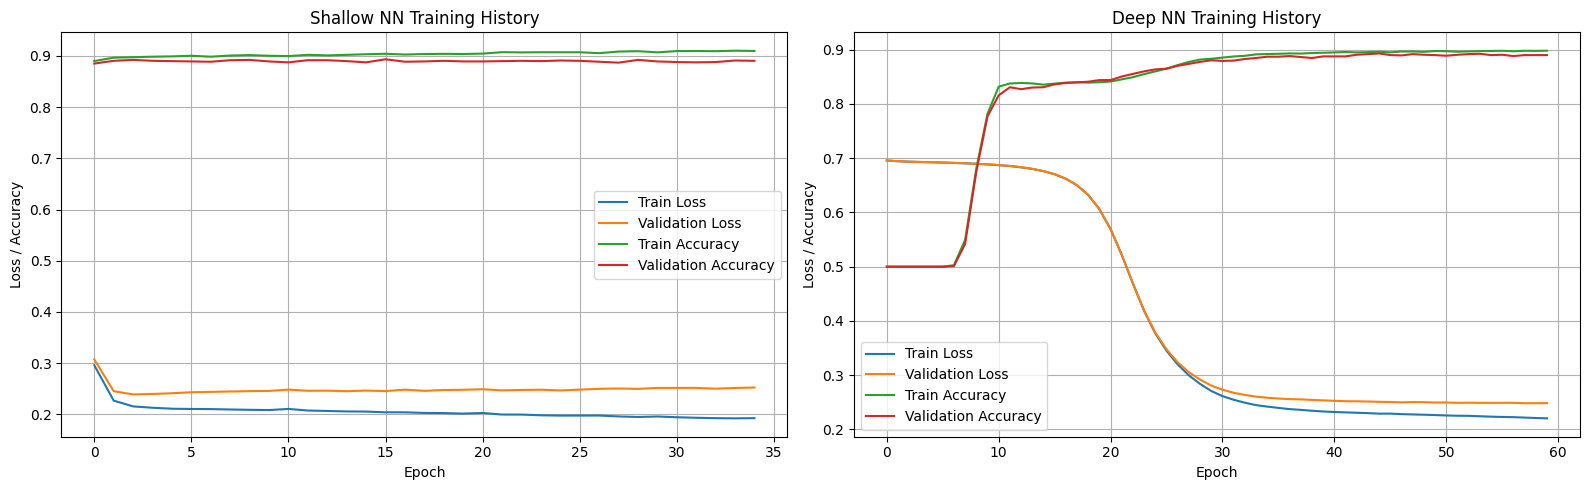

In [22]:
# STEP 19 - Required Visualization 1: Shallow vs Deep training history side-by-side 2x1 comparison plot

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def plot_training_history(ax, history, title):
    ax.plot(history["train_loss"], label="Train Loss")
    ax.plot(history["val_loss"], label="Validation Loss")
    ax.plot(history["train_acc"], label="Train Accuracy")
    ax.plot(history["val_acc"], label="Validation Accuracy")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss / Accuracy")
    ax.legend()
    ax.grid(True)

plot_training_history(axes[0], best_shallow_history, "Shallow NN Training History")
plot_training_history(axes[1], best_deep_history, "Deep NN Training History")

plt.tight_layout()
plt.show()

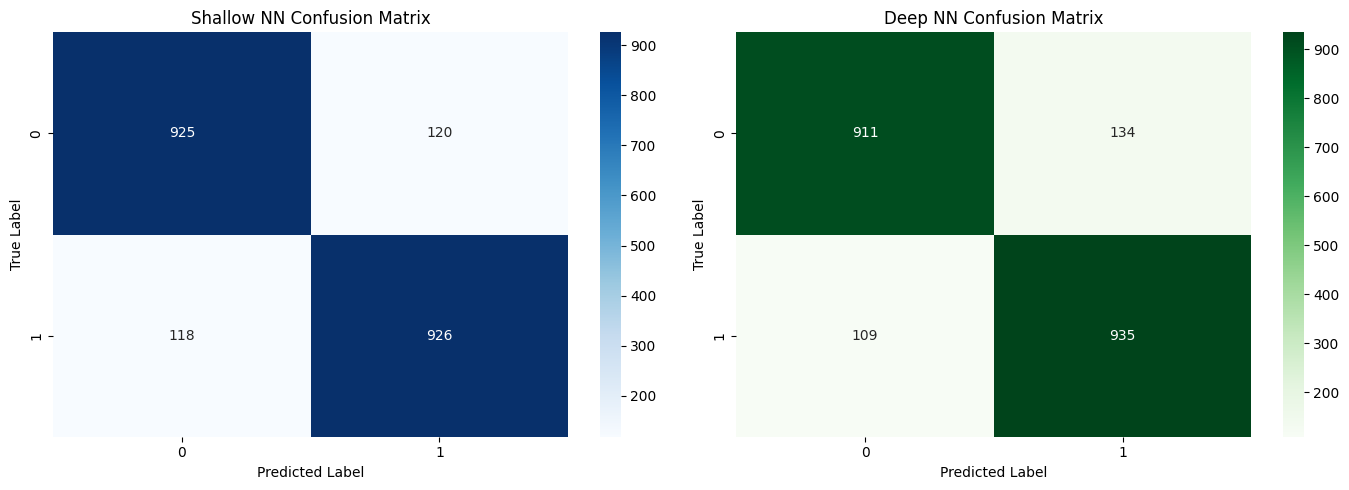

In [23]:
# STEP 20 - Required Visualization 2: Shallow vs Deep confusion matrix side-by-side heatmap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    shallow_test_metrics["cm"],
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Shallow NN Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(
    deep_test_metrics["cm"],
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("Deep NN Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

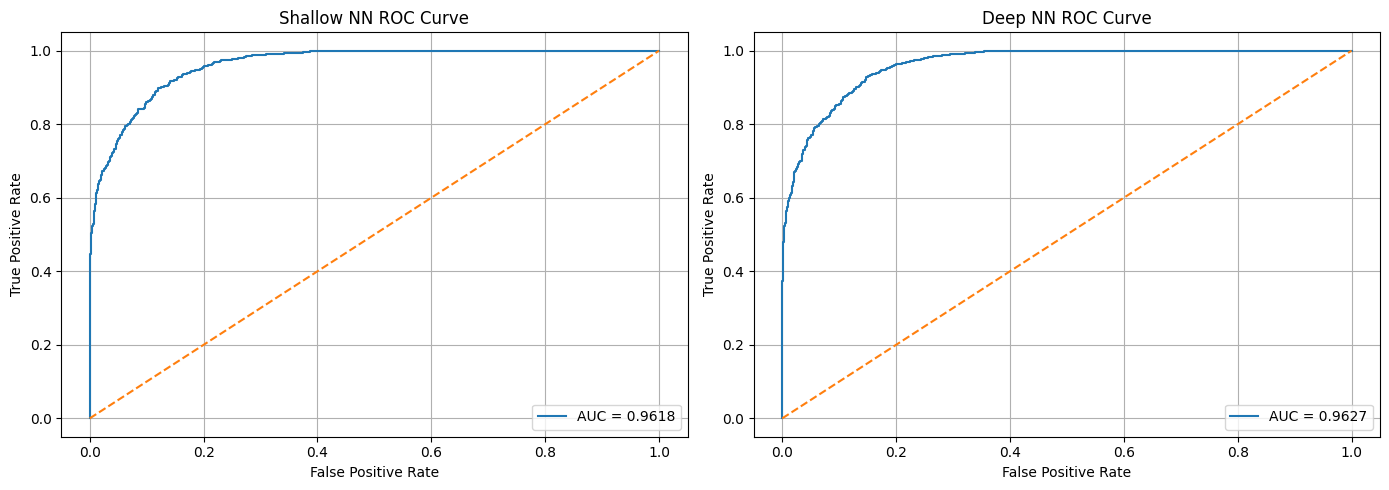

Shallow NN AUC: 0.9617664851784634
Deep NN AUC: 0.9627316724412912


In [24]:
# STEP 21 - Required Visualization 3: Shallow vs Deep ROC curve side-by-side plot with AUC score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    shallow_test_metrics["fpr"],
    shallow_test_metrics["tpr"],
    label=f"AUC = {shallow_test_metrics['auc']:.4f}"
)
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("Shallow NN ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    deep_test_metrics["fpr"],
    deep_test_metrics["tpr"],
    label=f"AUC = {deep_test_metrics['auc']:.4f}"
)
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("Deep NN ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Shallow NN AUC:", shallow_test_metrics["auc"])
print("Deep NN AUC:", deep_test_metrics["auc"])

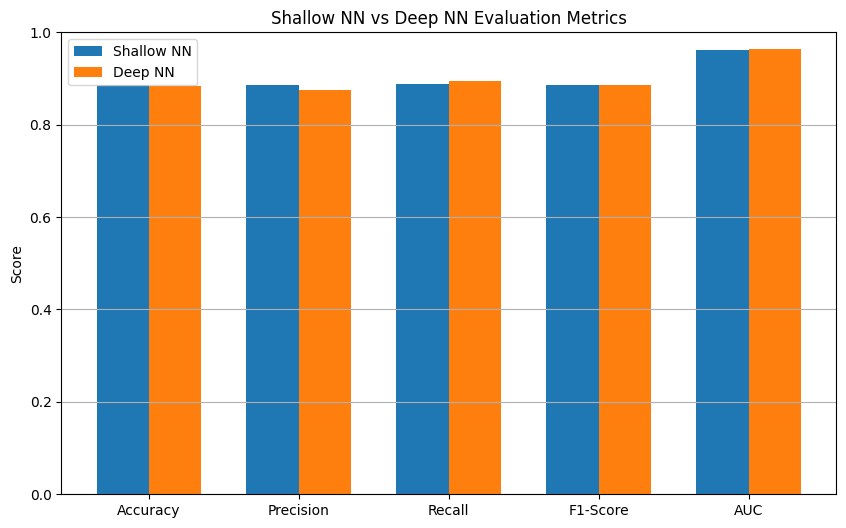

In [25]:
# STEP 22 - Required Visualization 4: Accuracy, Precision, Recall, F1, AUC grouped bar chart

metric_names = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]

shallow_values = [
    shallow_test_metrics["accuracy"],
    shallow_test_metrics["precision"],
    shallow_test_metrics["recall"],
    shallow_test_metrics["f1"],
    shallow_test_metrics["auc"]
]

deep_values = [
    deep_test_metrics["accuracy"],
    deep_test_metrics["precision"],
    deep_test_metrics["recall"],
    deep_test_metrics["f1"],
    deep_test_metrics["auc"]
]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, shallow_values, width, label="Shallow NN")
plt.bar(x + width / 2, deep_values, width, label="Deep NN")

plt.xticks(x, metric_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Shallow NN vs Deep NN Evaluation Metrics")
plt.legend()
plt.grid(axis="y")

plt.show()

In [26]:
# STEP 23 - Required Visualization 5: Shallow NN এবং Deep NN architecture summary table তৈরি করা

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_layer_summary(model, model_name):
    rows = []

    for layer_name, layer in model.named_modules():
        if layer_name != "" and len(list(layer.children())) == 0:
            rows.append({
                "Model": model_name,
                "Layer Name": layer_name,
                "Layer Type": layer.__class__.__name__,
                "Details": str(layer)
            })

    return pd.DataFrame(rows)


print("Shallow NN Architecture:")
print(best_shallow_model)

print("\nDeep NN Architecture:")
print(best_deep_model)

print("\nTrainable Parameters:")
print("Shallow NN:", count_trainable_parameters(best_shallow_model))
print("Deep NN:", count_trainable_parameters(best_deep_model))

shallow_structure_df = model_layer_summary(best_shallow_model, "Shallow NN")
deep_structure_df = model_layer_summary(best_deep_model, "Deep NN")

network_structure_df = pd.concat(
    [shallow_structure_df, deep_structure_df],
    ignore_index=True
)

display(network_structure_df)

Shallow NN Architecture:
ShallowNN(
  (network): Sequential(
    (0): Linear(in_features=222, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Deep NN Architecture:
DeepNN(
  (network): Sequential(
    (0): Linear(in_features=222, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable Parameters:
Shallow NN: 7169
Deep NN: 38913


,Model,Layer Name,Layer Type,Details
0,Shallow NN,network.0,Linear,"Linear(in_features=222, out_features=32, bias=..."
1,Shallow NN,network.1,ReLU,ReLU()
2,Shallow NN,network.2,Linear,"Linear(in_features=32, out_features=1, bias=True)"
3,Deep NN,network.0,Linear,"Linear(in_features=222, out_features=128, bias..."
4,Deep NN,network.1,ReLU,ReLU()
5,Deep NN,network.2,Dropout,"Dropout(p=0.3, inplace=False)"
6,Deep NN,network.3,Linear,"Linear(in_features=128, out_features=64, bias=..."
7,Deep NN,network.4,ReLU,ReLU()
8,Deep NN,network.5,Dropout,"Dropout(p=0.3, inplace=False)"
9,Deep NN,network.6,Linear,"Linear(in_features=64, out_features=32, bias=T..."


In [27]:
# STEP 24 - Required 3-5 sentence performance interpretation automatically generate করা

best_model_name = "Deep NN" if deep_test_metrics["f1"] >= shallow_test_metrics["f1"] else "Shallow NN"

shallow_gap = best_shallow_history["val_loss"][-1] - best_shallow_history["train_loss"][-1]
deep_gap = best_deep_history["val_loss"][-1] - best_deep_history["train_loss"][-1]

analysis_text = f"""
### Performance Interpretation & Analysis

The **{best_model_name}** performed better overall based on the final F1-score comparison on the test set.
The Shallow NN achieved an F1-score of **{shallow_test_metrics["f1"]:.4f}** and AUC of **{shallow_test_metrics["auc"]:.4f}**, while the Deep NN achieved an F1-score of **{deep_test_metrics["f1"]:.4f}** and AUC of **{deep_test_metrics["auc"]:.4f}**.
The training history shows whether the validation loss stays close to the training loss or starts increasing, which helps identify possible overfitting.
For this dataset, the deeper model may provide better representation power because it has multiple hidden layers, but its dropout and L2 regularization are important to reduce overfitting.
"""

display(Markdown(analysis_text))


### Performance Interpretation & Analysis

The **Shallow NN** performed better overall based on the final F1-score comparison on the test set. 
The Shallow NN achieved an F1-score of **0.8861** and AUC of **0.9618**, while the Deep NN achieved an F1-score of **0.8850** and AUC of **0.9627**. 
The training history shows whether the validation loss stays close to the training loss or starts increasing, which helps identify possible overfitting. 
For this dataset, the deeper model may provide better representation power because it has multiple hidden layers, but its dropout and L2 regularization are important to reduce overfitting.
